<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula10a_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
print(X.shape)
print(set(y))

(569, 30)
{np.int64(0), np.int64(1)}


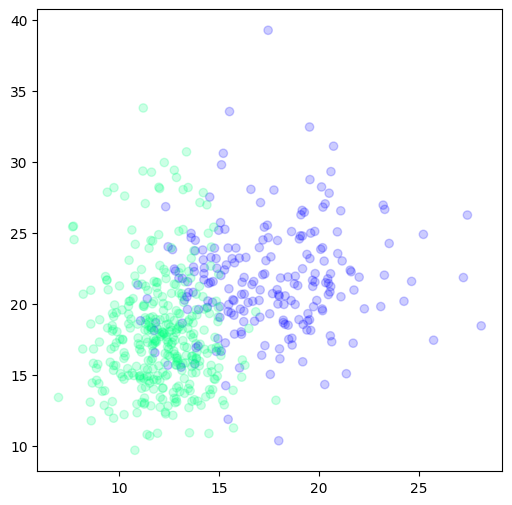

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2, cmap="winter")
plt.show()

#Principal Component Analisys (PCA)

In [98]:
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(569, 30)


In [99]:
print(pca.explained_variance_ratio_)

[9.82044672e-01 1.61764899e-02 1.55751075e-03 1.20931964e-04
 8.82724536e-05 6.64883951e-06 4.01713682e-06 8.22017197e-07
 3.44135279e-07 1.86018721e-07 6.99473205e-08 1.65908878e-08
 6.99641648e-09 4.78318305e-09 2.93549213e-09 1.41684926e-09
 8.29577731e-10 5.20405880e-10 4.08463983e-10 3.63313376e-10
 1.72849736e-10 1.27487508e-10 7.72682973e-11 6.28357715e-11
 3.57302295e-11 2.76396041e-11 8.14452259e-12 6.30211541e-12
 4.43666944e-12 1.55344680e-12]


In [100]:
print(sum(pca.explained_variance_ratio_))

0.9999999999999996


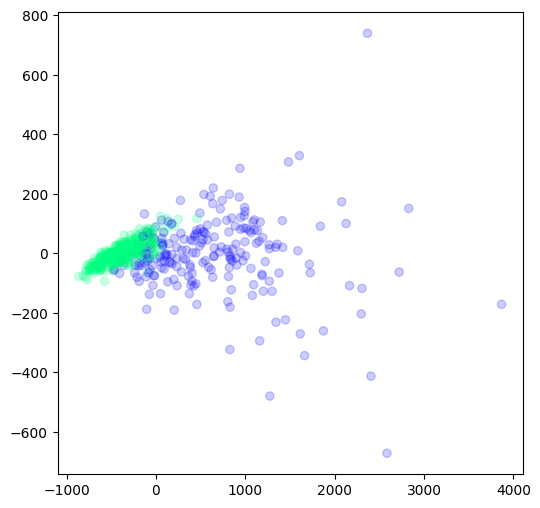

In [101]:
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.2, cmap="winter")
plt.show()

In [102]:
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier

splitter = RepeatedStratifiedKFold(n_splits=6, n_repeats=3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(model, X, y, cv=splitter, scoring='accuracy')
print(scores)
print(scores.mean())

[0.95789474 0.97894737 0.90526316 0.94736842 0.97894737 0.95744681
 0.97894737 0.94736842 0.97894737 0.93684211 0.94736842 0.94680851
 0.92631579 0.97894737 1.         0.97894737 0.94736842 0.95744681]
0.9583986562150056


In [103]:
scores = cross_val_score(model, X_pca, y, cv=splitter, scoring='accuracy')
print(scores)
print(scores.mean())

[0.93684211 0.94736842 0.93684211 0.95789474 0.96842105 0.92553191
 0.93684211 0.95789474 0.96842105 0.93684211 0.96842105 0.92553191
 0.93684211 0.91578947 1.         0.94736842 0.90526316 0.93617021]
0.9449048152295634


In [104]:
n_most_important_new_features = int(X.shape[1]*0.3)
print(n_most_important_new_features)
scores = cross_val_score(model, X_pca[:, :n_most_important_new_features], y, cv=splitter, scoring='accuracy')
print(scores)
print(scores.mean())

9
[0.94736842 0.94736842 0.91578947 0.94736842 0.96842105 0.95744681
 0.93684211 0.93684211 0.95789474 0.94736842 0.97894737 0.92553191
 0.94736842 0.94736842 0.96842105 0.96842105 0.93684211 0.95744681]
0.9496142839367923


In [105]:
print(sum(pca.explained_variance_ratio_[:n_most_important_new_features]))
print(sum(pca.explained_variance_ratio_[n_most_important_new_features:]))

0.9999997086651203
2.913348795325142e-07


In [106]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
def compare_feature_spaces(model):
  print("Espaço de características original")
  scores = cross_val_score(model, X, y, cv=splitter, scoring='accuracy')
  print(scores)
  print(scores.mean())
  print("Espaço de características reduzido")
  scores = cross_val_score(model, X_pca[:, :n_most_important_new_features], y, cv=splitter, scoring='accuracy')
  print(scores)
  print(scores.mean())
compare_feature_spaces(model)

Espaço de características original
[0.91578947 0.93684211 0.88421053 0.95789474 0.93684211 0.95744681
 0.91578947 0.90526316 0.94736842 0.90526316 0.94736842 0.90425532
 0.92631579 0.92631579 0.94736842 0.92631579 0.90526316 0.94680851]
0.9273733980340924
Espaço de características reduzido
[0.91578947 0.93684211 0.88421053 0.95789474 0.93684211 0.95744681
 0.91578947 0.90526316 0.94736842 0.90526316 0.94736842 0.90425532
 0.92631579 0.92631579 0.94736842 0.92631579 0.90526316 0.94680851]
0.9273733980340924


In [107]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
compare_feature_spaces(model)

Espaço de características original
[0.95789474 0.95789474 0.91578947 0.95789474 0.94736842 0.96808511
 0.95789474 0.93684211 0.95789474 0.93684211 0.94736842 0.96808511
 0.93684211 0.96842105 0.96842105 0.96842105 0.92631579 0.95744681]
0.9519845713574718
Espaço de características reduzido
[0.96842105 0.95789474 0.90526316 0.95789474 0.93684211 0.96808511
 0.94736842 0.94736842 0.94736842 0.92631579 0.93684211 0.9787234
 0.93684211 0.96842105 0.96842105 0.96842105 0.92631579 0.95744681]
0.9502364066193854


In [108]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
compare_feature_spaces(model)

Espaço de características original
[0.95789474 0.93684211 0.93684211 0.90526316 0.95789474 0.95744681
 0.92631579 0.93684211 0.96842105 0.90526316 0.93684211 0.94680851
 0.92631579 0.91578947 0.95789474 0.95789474 0.92631579 0.94680851]
0.9390941893741446
Espaço de características reduzido
[0.90526316 0.92631579 0.87368421 0.85263158 0.95789474 0.90425532
 0.89473684 0.88421053 0.95789474 0.88421053 0.88421053 0.90425532
 0.95789474 0.84210526 0.96842105 0.88421053 0.89473684 0.89361702]
0.9039193729003361


In [109]:
from sklearn.svm import SVC
model = SVC()
compare_feature_spaces(model)

Espaço de características original
[0.92631579 0.91578947 0.87368421 0.88421053 0.96842105 0.91489362
 0.92631579 0.92631579 0.95789474 0.85263158 0.91578947 0.90425532
 0.92631579 0.90526316 0.93684211 0.91578947 0.90526316 0.91489362]
0.9150491476919248
Espaço de características reduzido
[0.92631579 0.92631579 0.89473684 0.88421053 0.96842105 0.91489362
 0.93684211 0.93684211 0.94736842 0.88421053 0.92631579 0.91489362
 0.93684211 0.90526316 0.93684211 0.94736842 0.89473684 0.91489362]
0.9220729127784


In [110]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
compare_feature_spaces(model)

Espaço de características original
[0.92631579 0.93684211 0.85263158 0.93684211 0.93684211 0.91489362
 0.94736842 0.94736842 0.91578947 0.88421053 0.92631579 0.90425532
 0.90526316 0.89473684 0.98947368 0.93684211 0.92631579 0.93617021]
0.9232487246485006
Espaço de características reduzido
[0.91578947 0.93684211 0.87368421 0.95789474 0.90526316 0.91489362
 0.94736842 0.89473684 0.93684211 0.93684211 0.90526316 0.92553191
 0.92631579 0.91578947 0.92631579 0.94736842 0.91578947 0.88297872]
0.920306084359836


In [111]:
pca = PCA(n_components=0.9999)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(569, 5)


In [112]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    PCA(n_components=0.9999),
    RandomForestClassifier(n_estimators=100, random_state=42)
)
scores = cross_val_score(model, X, y, cv=splitter, scoring='accuracy')
print(scores)
print(scores.mean())

[0.93684211 0.93684211 0.91578947 0.95789474 0.97894737 0.94680851
 0.93684211 0.93684211 0.92631579 0.93684211 0.97894737 0.93617021
 0.93684211 0.93684211 0.95789474 0.96842105 0.93684211 0.96808511]
0.9461117332337936


# PCA fail

In [133]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100,
                  centers=[[0.1, 0.1], [0.0, 0.4],
                           [0.3, 0.1], [0.2, 0.4],
                           [0.5, 0.1], [0.4, 0.4],
                           [0.7, 0.1], [0.6, 0.4],
                           [0.9, 0.1], [0.8, 0.4],
                           [1.1, 0.1], [1.0, 0.4],
                           ],
                  n_features=2,
                  cluster_std=0.05,
                  random_state=42)
y = y % 2
print(X.shape)

(100, 2)


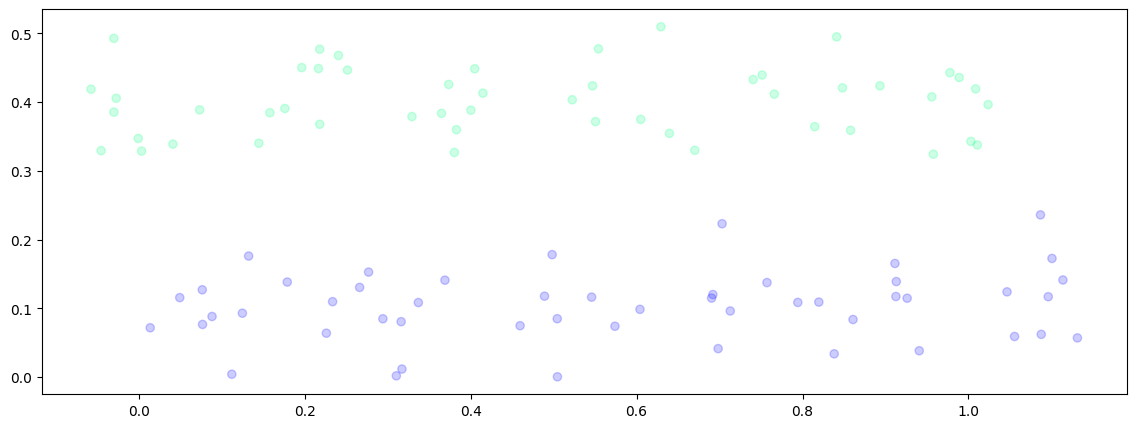

In [134]:
plt.figure(figsize=(14,5))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2, cmap="winter")
plt.show()

In [135]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

model = Perceptron()
model.fit(X, y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))

1.0


[-0.08379248  4.49809577] -1.0


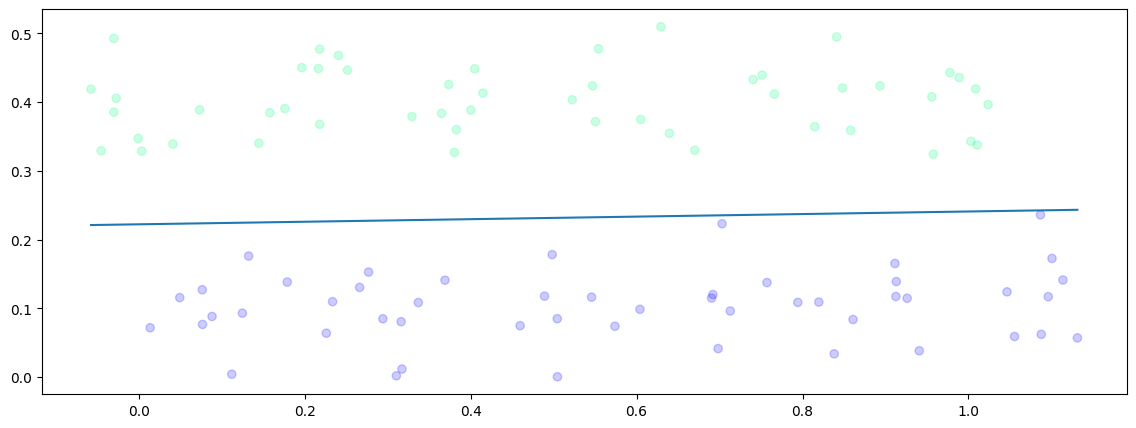

In [136]:
import numpy as np

def plotHyperplan(model, X, y):
  xs = np.array([X[:,0].min(), X[:,0].max()])
  vector = model.coef_[0]
  bias = model.intercept_[0]
  print(vector, bias)
  ys = (-vector[0]*xs - bias)/vector[1]
  plt.plot(xs, ys)

plt.figure(figsize=(14,5))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2, cmap="winter")
plotHyperplan(model, X, y)
plt.show()


In [137]:
model.fit(X[:,1:], y)
y_pred = model.predict(X[:,1:])
print(accuracy_score(y, y_pred))

1.0


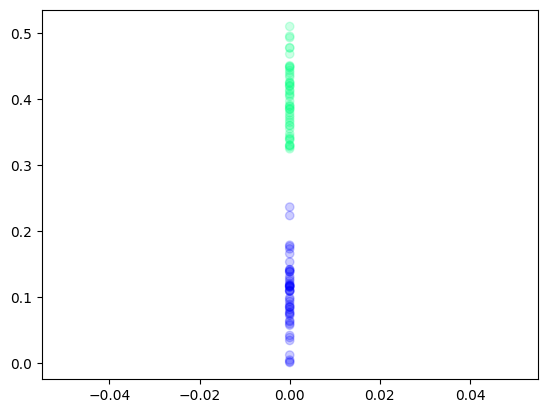

In [138]:
plt.scatter(np.zeros_like(X[:,0]), X[:,1], c=y, alpha=0.2, cmap="winter")
plt.show()

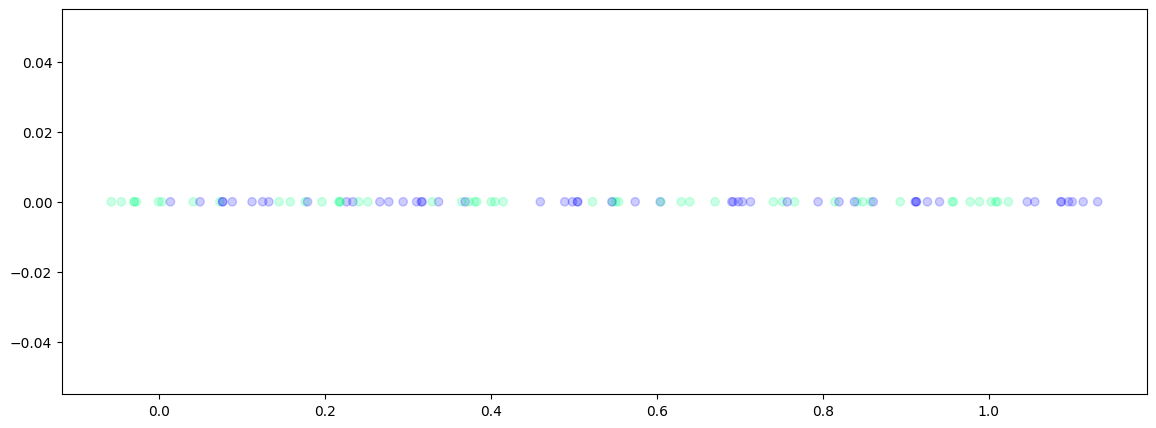

In [139]:
plt.figure(figsize=(14,5))
plt.scatter(X[:,0], np.zeros_like(X[:,1]), c=y, alpha=0.2, cmap="winter")
plt.show()

In [140]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(100, 1)


In [141]:
model.fit(X_pca, y)
y_pred = model.predict(X_pca)
print(accuracy_score(y, y_pred))

0.47


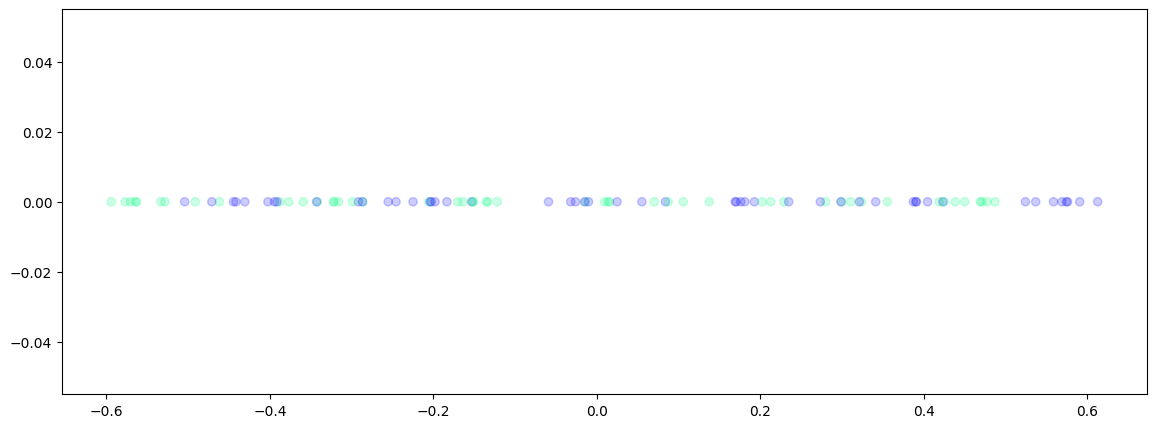

In [143]:
plt.figure(figsize=(14,5))
plt.scatter(X_pca, np.zeros_like(X_pca), c=y, alpha=0.2, cmap="winter")
plt.show()
#

In [144]:
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    PCA(n_components=1),
    Perceptron()
)
model.fit(X, y)
y_pred = model.predict(X)
print(accuracy_score(y, y_pred))

0.81


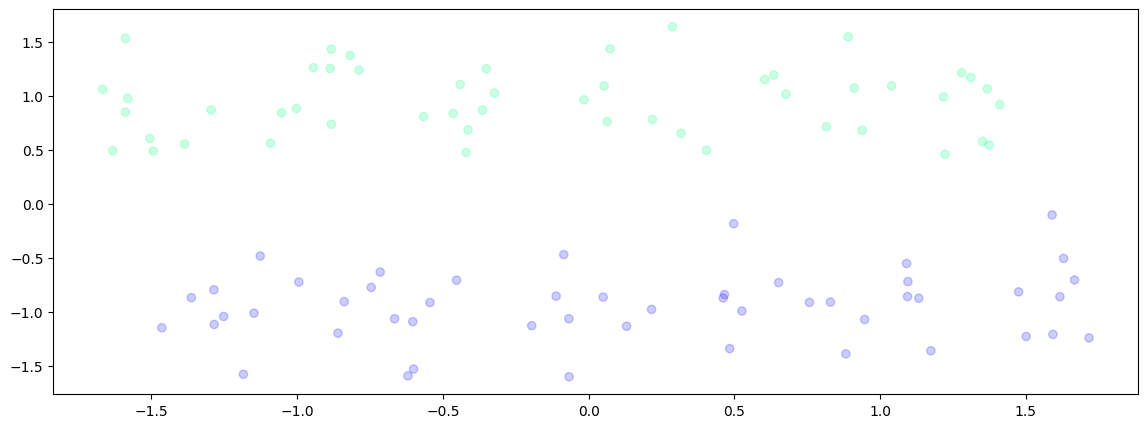

In [146]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
plt.figure(figsize=(14,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y, alpha=0.2, cmap="winter")
plt.show()
#